<a href="https://colab.research.google.com/github/AJAXSINGH/DAA-PROJECT/blob/main/DAA3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== KRUSKAL'S MST ==========
Edge (0 - 3)   Weight = 5
Edge (2 - 4)   Weight = 5
Edge (3 - 5)   Weight = 6
Edge (0 - 1)   Weight = 7
Edge (1 - 4)   Weight = 7
Edge (4 - 6)   Weight = 9

Total MST Cost = 39

========== PRIM'S MST ==========
Edge (0 - 3)   Weight = 5
Edge (3 - 5)   Weight = 6
Edge (0 - 1)   Weight = 7
Edge (1 - 4)   Weight = 7
Edge (4 - 2)   Weight = 5
Edge (4 - 6)   Weight = 9

Total MST Cost = 39


  Vertices     Kruskal(ms)        Prim(ms)
---------------------------------------------
        20          0.0148          0.0140
        40          0.0366          0.0404
        60          0.0814          0.0785
        80          0.1250          0.1333
       100          0.2648          0.1927


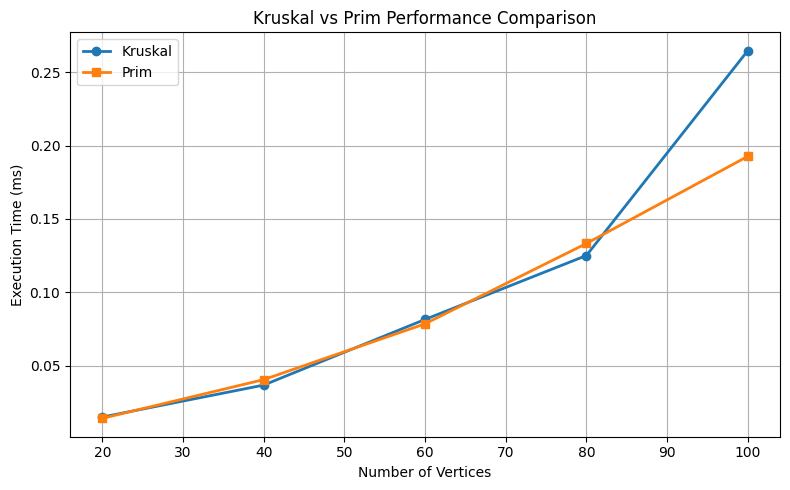

In [1]:
import heapq
import time
import random
import matplotlib.pyplot as plt


# ---------------- UNION-FIND FOR KRUSKAL ----------------

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])   # Path Compression
        return self.parent[x]

    def union(self, x, y):
        rx = self.find(x)
        ry = self.find(y)

        if rx == ry:
            return False

        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx

        self.parent[ry] = rx

        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1

        return True


# ---------------- KRUSKAL'S ALGORITHM ----------------

def kruskal(n, edges):
    edges.sort()

    uf = UnionFind(n)

    mst = []
    total_cost = 0

    for weight, u, v in edges:
        if uf.union(u, v):
            mst.append((u, v, weight))
            total_cost += weight

            if len(mst) == n - 1:
                break

    return mst, total_cost


# ---------------- PRIM'S ALGORITHM ----------------

def prim(n, adj, start=0):

    INF = float("inf")

    key = [INF] * n
    parent = [-1] * n
    in_mst = [False] * n

    key[start] = 0

    pq = [(0, start)]

    mst = []
    total_cost = 0

    while pq:

        weight, u = heapq.heappop(pq)

        if in_mst[u]:
            continue

        in_mst[u] = True

        if parent[u] != -1:
            mst.append((parent[u], u, weight))
            total_cost += weight

        for v, wt in adj.get(u, []):

            if not in_mst[v] and wt < key[v]:
                key[v] = wt
                parent[v] = u
                heapq.heappush(pq, (wt, v))

    return mst, total_cost


# ---------------- SAMPLE GRAPH ----------------

n = 7

edges = [
    (7, 0, 1),
    (5, 0, 3),
    (8, 1, 2),
    (9, 1, 3),
    (7, 1, 4),
    (5, 2, 4),
    (15, 3, 4),
    (6, 3, 5),
    (8, 4, 5),
    (9, 4, 6),
    (11, 5, 6)
]

adj = {}

for weight, u, v in edges:
    adj.setdefault(u, []).append((v, weight))
    adj.setdefault(v, []).append((u, weight))


# ---------------- RUN BOTH ALGORITHMS ----------------

kruskal_mst, kruskal_cost = kruskal(n, edges[:])
prim_mst, prim_cost = prim(n, adj)


print("========== KRUSKAL'S MST ==========")

for u, v, w in kruskal_mst:
    print(f"Edge ({u} - {v})   Weight = {w}")

print(f"\nTotal MST Cost = {kruskal_cost}")


print("\n========== PRIM'S MST ==========")

for u, v, w in prim_mst:
    print(f"Edge ({u} - {v})   Weight = {w}")

print(f"\nTotal MST Cost = {prim_cost}")


# ---------------- PERFORMANCE ANALYSIS ----------------

sizes = [20, 40, 60, 80, 100]

kruskal_times = []
prim_times = []

print("\n")
print(f"{'Vertices':>10} {'Kruskal(ms)':>15} {'Prim(ms)':>15}")
print("-" * 45)

for vertices in sizes:

    random_edges = []

    for i in range(vertices):
        for j in range(i + 1, vertices):
            if random.random() < 0.15:
                random_edges.append(
                    (random.randint(1, 100), i, j)
                )

    graph = {}

    for w, u, v in random_edges:
        graph.setdefault(u, []).append((v, w))
        graph.setdefault(v, []).append((u, w))

    # Kruskal Timing
    start = time.perf_counter()

    for _ in range(50):
        kruskal(vertices, random_edges[:])

    kruskal_time = (time.perf_counter() - start) / 50 * 1000

    # Prim Timing
    start = time.perf_counter()

    for _ in range(50):
        prim(vertices, graph)

    prim_time = (time.perf_counter() - start) / 50 * 1000

    kruskal_times.append(kruskal_time)
    prim_times.append(prim_time)

    print(f"{vertices:>10} {kruskal_time:>15.4f} {prim_time:>15.4f}")


# ---------------- PERFORMANCE GRAPH ----------------

plt.figure(figsize=(8, 5))

plt.plot(
    sizes,
    kruskal_times,
    marker='o',
    linewidth=2,
    label="Kruskal"
)

plt.plot(
    sizes,
    prim_times,
    marker='s',
    linewidth=2,
    label="Prim"
)

plt.title("Kruskal vs Prim Performance Comparison")
plt.xlabel("Number of Vertices")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
